# Co-Dependent Geometry: Small-Molecule Structural Re-Conformation

In standard text-based Transformers (like the Shakespeare GPT), attention operates exclusively over a 1D sequence of tokens. The distance between words is tracked linearly via simple positional encodings. 

However, physical molecules don't exist in 1D text strings. To solve this, AlphaFold introduced the **EvoFormer**, which maintains and continually updates two entirely different data arrays simultaneously:

1. **The Node Track (MSA Representation)** ($N \times C_m$): Represents the individual components of the system. In this small-molecule notebook, each node is a specific atom (e.g., Carbon, Nitrogen, Oxygen) mapped to its hidden chemical embedding.
2. **The Pair Track (Relation Matrix)** ($N \times N \times C_z$): Represents the spatial and structural relationships between *every single pair* of atoms. Crucially, this track explicitly maps the 3D Euclidean distances and chemical bond constraints between them.

---

## Optimized Engineering Upgrades Implemented:
1. **Local CSV Offline Chemical Intake:** Replaced unreliable web API calls with a fast, thread-safe direct ingestion pipeline loading local CSV data dumps.
2. **Chemical Structural Pair Tokenization:** Maps explicit covalent bond topologies (single, double, triple, aromatic) directly into the initial Pair track embeddings, ensuring the network is not structurally blind when spatial distances are masked.
3. **Gradual Curriculum Masking:** Trains the network across increasing geometric stress thresholds (5% $\rightarrow$ 10% $\rightarrow$ 30% blind spatial occlusion).

In [1]:
import os
import sys
!{sys.executable} -m pip install -q rdkit matplotlib torch pandas


[notice] A new release of pip is available: 23.2.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [ ]:
import math
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import AllChem
import warnings
warnings.filterwarnings('ignore')

# --- Technical Hyperparameters ---
max_atoms = 24         # Normalized padded spatial array size (N)
c_m = 32               # Node feature dimension
c_z = 32               # Pair track relation feature dimension
device = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'
print(f"Running model on hardware accelerator: {device}")

Running model on hardware accelerator: mps


### 1. Offline Chemical Ingestion and Local Dataset Setup

Fetching data from PubChem API (i.e. https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/cid/2244,2445,1,10000,100000/property/IUPACName,Title,CanonicalSMILES/JSON) is unreliable and often results in `503 Service Unavailable` errors due to rate limits and server load.
Instead we loading xml version from ftp (https://ftp.ncbi.nih.gov/pubchem/Compound/CURRENT-Full/XML/) and use ./data/evoformer/to_csv.py to transform the downloaded XML (~1Gb per part) into local CSV structure asset (`Compound500k.csv`). This approach reads structural SMILES tokens natively, avoiding flaky external dependencies.

In [3]:
csv_source_path = './data/evoformer/Compound500k.csv'

def ingest_local_chemical_data(path, required_count=10000):
    if not os.path.exists(path):
        # Graceful fallback logic with synthetic sample dataframe if local run lacks file locally
        print(f"[Warning] Source CSV asset not detected at {path}. Synthesizing working sample framework for code compliance...")
        synthetic_data = {
            'cid': list(range(1, 11)),
            'smiles_canonical': ['CC(=O)OC1=CC=CC=C1C(=O)O', 'C1=CC=C(C=C1)C(=O)O', 'CC(C)CC1=CC=C(C=C1)C(C)C(=O)O',
                                 'CCN(CC)C(=O)C1CN(C2=CC=CC3=C2C1=CC=C3)C', 'CN1C=NC2=C1C(=O)N(C(=O)N2C)C',
                                 'CC12CCC3C(C1CCC2O)CCC4=CC(=O)CCC34C', 'CC1=C(C(=O)C(=C(C1=O)OC)OC)C/C=C(\C)/CC/C=C(\C)/CCC=C(C)C',
                                 'C1=CC(=C(C=C1)O)O', 'C1=CC=NC=C1', 'C1(=CC=CC=C1)O'] * 100
        }
        df = pd.DataFrame(synthetic_data)
        df.rename(columns={'smiles_canonical': 'CanonicalSMILES', 'cid': 'CID'}, inplace=True)
        return df
        
    print(f"Reading local compound database asset: '{path}'")
    # Standard compound datasets store SMILES strings inside 'smiles_canonical' or 'smiles'
    raw_df = pd.read_csv(path)
    
    # Identify columns flexibly
    smiles_col = [col for col in raw_df.columns if 'smiles' in col.lower()]
    cid_col = [col for col in raw_df.columns if 'cid' in col.lower()]
    
    df_processed = pd.DataFrame()
    df_processed['CID'] = raw_df[cid_col[0]] if cid_col else raw_df.index
    df_processed['CanonicalSMILES'] = raw_df[smiles_col[0]] if smiles_col else raw_df.iloc[:, 1]
    
    # Discard null values
    df_processed = df_processed.dropna(subset=['CanonicalSMILES']).reset_index(drop=True)
    print(f"Ingestion completed. Total compounds loaded from disk: {len(df_processed)}")
    return df_processed

chemical_df = ingest_local_chemical_data(csv_source_path)

Reading local compound database asset: './data/evoformer/Compound500k.csv'
Ingestion completed. Total compounds loaded from disk: 444810


In [4]:
from rdkit import RDLogger

def compile_tensors_from_warehouse(df, limit=1000, max_n=24, feat_dim=32, pair_dim=32):
    # 1. Mute low-level RDKit C++ stderr logs to clean up your notebook console
    RDLogger.DisableLog('rdApp.*')
    
    node_data = []
    pair_data = []
    bond_types = {Chem.BondType.SINGLE: 1.0, Chem.BondType.DOUBLE: 2.0, 
                  Chem.BondType.TRIPLE: 3.0, Chem.BondType.AROMATIC: 4.0}
                  
    print(f"Compiling 3D physical coordinates and covalent topologies for a sub-sample of {limit} compounds...")
    success_count = 0
    skipped_count = 0
    
    for idx, row in df.iterrows():
        if limit > 0 and success_count >= limit:
            break
        smiles = row['CanonicalSMILES']
        
        try:
            mol = Chem.MolFromSmiles(str(smiles))
            if mol is None:
                print(f"[MALFORMED SMILES] Skipped Row {idx}: {smiles}")
                skipped_count += 1
                continue
                
            mol = Chem.AddHs(mol)
            
            # Use deterministic conformer parameter seeds
            embed_params = AllChem.ETKDGv3()
            embed_params.randomSeed = 42
            if AllChem.EmbedMolecule(mol, embed_params) == -1:
                print(f"[EMBEDDING FAILED] Conformation geometry generation failed: {smiles}")
                skipped_count += 1
                continue
                
            # EXPLICIT GEOMETRY SANITY CHECK:
            # Forcefields (MMFF/UFF) will return -1 if they hit unmappable metal ions or atom states
            if AllChem.MMFFOptimizeMolecule(mol) == -1:
                print(f"[INVALID FORCEFIELD] Structure contains unresolvable atoms/charges: {smiles}")
                skipped_count += 1
                continue
                
            conformer = mol.GetConformer()
            num_atoms = mol.GetNumAtoms()
            
            if num_atoms > max_n:
                # Silent skip for oversized molecules to maintain pad array sizes
                continue
                
            nodes = torch.zeros(max_n, feat_dim)
            for i in range(num_atoms):
                nodes[i, 0] = mol.GetAtomWithIdx(i).GetAtomicNum()
                
            pairs = torch.zeros(max_n, max_n, pair_dim)
            coords = np.array([list(conformer.GetAtomPosition(i)) for i in range(num_atoms)])
            dist_matrix = torch.cdist(torch.tensor(coords).float(), torch.tensor(coords).float())
            pairs[:num_atoms, :num_atoms, 0] = dist_matrix
            
            for bond in mol.GetBonds():
                idx1 = bond.GetBeginAtomIdx()
                idx2 = bond.GetEndAtomIdx()
                b_val = bond_types.get(bond.GetBondType(), 1.0)
                if idx1 < max_n and idx2 < max_n:
                    pairs[idx1, idx2, 1] = b_val
                    pairs[idx2, idx1, 1] = b_val
                    
            node_data.append(nodes)
            pair_data.append(pairs)
            success_count += 1
            
        except Exception as py_err:
            print(f"{idx}: [EXECUTION EXCEPTION] Unexpected Python error processing {smiles}: {py_err}")
            skipped_count += 1
            continue
            
    # Re-enable logs if you need them later in your notebook pipeline
    RDLogger.EnableLog('rdApp.*')
    
    print(f"\nParsing summary: Saved {success_count} valid compounds. Explicitly filtered out {skipped_count} problematic SMILES.")
    return torch.stack(node_data), torch.stack(pair_data)

'''
def compile_tensors_from_warehouse(df, limit=1000, max_n=24, feat_dim=32, pair_dim=32):
    node_data = []
    pair_data = []
    bond_types = {Chem.BondType.SINGLE: 1.0, Chem.BondType.DOUBLE: 2.0, 
                  Chem.BondType.TRIPLE: 3.0, Chem.BondType.AROMATIC: 4.0}
                  
    print(f"Compiling 3D physical coordinates and covalent topologies for a sub-sample of {limit} compounds...")
    success_count = 0
    
    for _, row in df.iterrows():
        if success_count >= limit:
            break
        smiles = row['CanonicalSMILES']
        
        try:
            mol = Chem.MolFromSmiles(str(smiles))
            if mol is None:
                continue
            mol = Chem.AddHs(mol)
            
            embed_params = AllChem.ETKDGv3()
            embed_params.randomSeed = 42
            if AllChem.EmbedMolecule(mol, embed_params) == -1:
                continue
                
            AllChem.MMFFOptimizeMolecule(mol)
            conformer = mol.GetConformer()
            num_atoms = mol.GetNumAtoms()
            
            if num_atoms > max_n:
                continue
                
            nodes = torch.zeros(max_n, feat_dim)
            for i in range(num_atoms):
                nodes[i, 0] = mol.GetAtomWithIdx(i).GetAtomicNum()
                
            pairs = torch.zeros(max_n, max_n, pair_dim)
            coords = np.array([list(conformer.GetAtomPosition(i)) for i in range(num_atoms)])
            dist_matrix = torch.cdist(torch.tensor(coords).float(), torch.tensor(coords).float())
            pairs[:num_atoms, :num_atoms, 0] = dist_matrix
            
            # Chemical Structural Pair Tokenization Mapping
            for bond in mol.GetBonds():
                idx1 = bond.GetBeginAtomIdx()
                idx2 = bond.GetEndAtomIdx()
                b_val = bond_types.get(bond.GetBondType(), 1.0)
                if idx1 < max_n and idx2 < max_n:
                    pairs[idx1, idx2, 1] = b_val
                    pairs[idx2, idx1, 1] = b_val
                    
            node_data.append(nodes)
            pair_data.append(pairs)
            success_count += 1
            
        except:
            print(f"[Warning] Failed to process SMILES: {smiles}. Skipping entry.")
            continue
            
    if len(node_data) == 0:
        raise ValueError("No valid configurations could be mapped! Check your local CSV SMILES syntax compatibility.")
        
    return torch.stack(node_data), torch.stack(pair_data)
'''
nodes_db, pairs_db = compile_tensors_from_warehouse(chemical_df, limit=1000, max_n=max_atoms, feat_dim=c_m, pair_dim=c_z)
print(f"Successfully parsed dataset tensors! Nodes shape: {nodes_db.shape}, Pairs shape: {pairs_db.shape}")


Compiling 3D physical coordinates and covalent topologies for a sub-sample of 1000 compounds...
[EMBEDDING FAILED] Conformation geometry generation failed: CC(=CCCC(=CCCC(=CCCC(=CCCC(=CCCC(=CCCC(=CCCC(=CCCC(=CCCC(=CCCC(=CCOP(=O)(O)OP(=O)(O)OC1C(C(C(C(O1)CO)OC2C(C(C(C(O2)CO)O)O)NC(=O)C)O)NC(=O)C)C)C)C)C)C)C)C)C)C)C)C
[INVALID FORCEFIELD] Structure contains unresolvable atoms/charges: O[As](=O)([O-])[O-]
[INVALID FORCEFIELD] Structure contains unresolvable atoms/charges: O[As](=O)(O)O
[EMBEDDING FAILED] Conformation geometry generation failed: CCCCCCCCCCCC(CC(=O)NC1C(C(C(OC1OCC2C(C(C(C(O2)OP(=O)(O)O)NC(=O)CC(CCCCCCCCCCC)O)OC(=O)CC(CCCCCCCCCCC)O)O)CO)O)OC(=O)CC(CCCCCCCCCCC)O)O
[INVALID FORCEFIELD] Structure contains unresolvable atoms/charges: Br
[EMBEDDING FAILED] Conformation geometry generation failed: CC(C(=O)NC(CCC(=O)NC(CCCC(C(=O)O)N)C(=O)NC(C)C(=O)NC(C)C(=O)O)C(=O)O)NC(=O)C(C)OC1C(C(OC(C1O)CO)OP(=O)(O)OP(=O)(O)OCC=C(C)CCC=C(C)CCC=C(C)CCC=C(C)CCC=C(C)CCC=C(C)CCC=C(C)CCC=C(C)CCC=C(C)

### 2. Architectural Analysis: Why Distance Predictions Degrade under Naive Activations

#### The Trap of Direct ReLU / Hard Projections
When mapping latent pair embeddings back to real spatial dimensions using an explicit equation like $\text{ReLU}(Wz + b)$, structural convergence routinely collapses due to **gradient expiration**. In early training epochs, if random matrix parameters project the distances into negative space, ReLU clamps the values cleanly to `0.0`.

Because the derivative of a flat ReLU step at zero is exactly zero ($0.0$), no training error gradient propagates backward into the Triangle Update loops. The network encounters a "Dead Neuron" crisis, lock-stepping predictions into an immutable blank matrix.

#### Why Softplus Provides a Mathematically Smooth Alternative
To resolve this, we implement the **Softplus** function:
$$\text{Softplus}(x) = \frac{1}{\beta} \cdot \log(1 + e^{\beta \cdot x})$$

Softplus provides a smooth curve that guarantees all computed matrix coordinates remain strictly positive ($> 0.0$), satisfying physical matter constraints, while preserving continuous non-zero derivatives everywhere across the real number line. This allows geometric adjustments to propagate all the way back to the node tracks, avoiding dead zones.

In [5]:
class PairBiasedAttention(nn.Module):
    def __init__(self, c_m, c_z, n_heads=4):
        super().__init__()
        self.n_heads = n_heads
        self.head_dim = c_m // n_heads
        
        self.q_linear = nn.Linear(c_m, c_m, bias=False)
        self.k_linear = nn.Linear(c_m, c_m, bias=False)
        self.v_linear = nn.Linear(c_m, c_m, bias=False)
        self.pair_to_bias = nn.Linear(c_z, n_heads, bias=False)
        self.out_proj = nn.Linear(c_m, c_m)
        
    def forward(self, m, z):
        B, N, _ = m.shape
        q = self.q_linear(m).view(B, N, self.n_heads, self.head_dim).transpose(1, 2)
        k = self.k_linear(m).view(B, N, self.n_heads, self.head_dim).transpose(1, 2)
        v = self.v_linear(m).view(B, N, self.n_heads, self.head_dim).transpose(1, 2)
        
        scores = torch.matmul(q, k.transpose(-2, -1)) * (self.head_dim ** -0.5)
        spatial_bias = self.pair_to_bias(z).permute(0, 3, 1, 2)
        
        attn = F.softmax(scores + spatial_bias, dim=-1)
        context = torch.matmul(attn, v).transpose(1, 2).contiguous().view(B, N, c_m)
        return self.out_proj(context)

class TriangleMultiplicativeUpdate(nn.Module):
    def __init__(self, c_z):
        super().__init__()
        self.layer_norm = nn.LayerNorm(c_z)
        self.lin_left = nn.Linear(c_z, c_z)
        self.lin_right = nn.Linear(c_z, c_z)
        self.out_proj = nn.Linear(c_z, c_z)
        
    def forward(self, z):
        z_norm = self.layer_norm(z)
        left = torch.sigmoid(self.lin_left(z_norm))
        right = torch.sigmoid(self.lin_right(z_norm))
        update = torch.einsum("bikc,bjkc->bijc", left, right)
        return self.out_proj(update)

class EvoFormerStructuralBlock(nn.Module):
    def __init__(self, c_m, c_z):
        super().__init__()
        self.attn = PairBiasedAttention(c_m, c_z)
        self.tri_update = TriangleMultiplicativeUpdate(c_z)
        self.ln_m = nn.LayerNorm(c_m)
        self.ln_z = nn.LayerNorm(c_z)
        self.ff_m = nn.Sequential(nn.Linear(c_m, c_m), nn.ReLU(), nn.Linear(c_m, c_m))

    def forward(self, m, z):
        m = m + self.attn(self.ln_m(m), z)
        m = m + self.ff_m(self.ln_m(m))
        z = z + self.tri_update(self.ln_z(z))
        return m, z

class MoleculeConformationRefiner(nn.Module):
    def __init__(self, c_m, c_z, depth=3):
        super().__init__()
        self.atom_embed = nn.Embedding(100, c_m)
        self.pair_embed = nn.Linear(c_z, c_z)
        self.blocks = nn.ModuleList([EvoFormerStructuralBlock(c_m, c_z) for _ in range(depth)])
        self.predict_distance = nn.Linear(c_z, 1)
        
    def forward(self, m, z):
        m_mapped = self.atom_embed(m[:, :, 0].long())
        z_mapped = self.pair_embed(z)
        
        for block in self.blocks:
            m_mapped, z_mapped = block(m_mapped, z_mapped)
            
        return F.softplus(self.predict_distance(z_mapped)).squeeze(-1)

### 3. Progressive Curriculum Masking Loop

We train the updated EvoFormer using a gradual spatial curriculum. The model starts by reconstructing minor geometric oclusions (5%), scales up to moderate masking checkpoints (10%), and concludes under high geometric stress (30% total matrix blackout).

In [6]:
model = MoleculeConformationRefiner(c_m, c_z, depth=3).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=8e-4, weight_decay=1e-4)

split_idx = int(len(nodes_db) * 0.9)
train_m, val_m = nodes_db[:split_idx].to(device), nodes_db[split_idx:].to(device)
train_z, val_z = pairs_db[:split_idx].to(device), pairs_db[split_idx:].to(device)

curriculum_stages = [
    {"epochs": 100, "mask_ratio": 0.05, "label": "Stage 1: Stable Initialization (5% Mask)"},
    {"epochs": 100, "mask_ratio": 0.10, "label": "Stage 2: Medium Topology Stress (10% Mask)"},
    {"epochs": 150, "mask_ratio": 0.30, "label": "Stage 3: Advanced Structural Reconstruction (30% Mask)"}
]

batch_size = 32
print("Starting Multi-Stage Structural Masking Curriculum...")

for stage in curriculum_stages:
    print(f"\n--- Transitioning to {stage['label']} ---")
    ratio = stage["mask_ratio"]
    
    for epoch in range(stage["epochs"]):
        model.train()
        permutation = torch.randperm(train_m.size(0))
        epoch_loss = 0.0
        batches_run = 0
        
        for i in range(0, train_m.size(0), batch_size):
            indices = permutation[i:i+batch_size]
            b_m, b_z = train_m[indices], train_z[indices]
            
            target_dist = b_z[:, :, :, 0]
            corrupted_z = b_z.clone()
            
            mask = torch.rand(b_z.size(0), max_atoms, max_atoms, device=device) < ratio
            mask = (mask | mask.transpose(-2, -1))
            
            corrupted_z[:, :, :, 0] = torch.where(mask, torch.zeros_like(corrupted_z[:, :, :, 0]), corrupted_z[:, :, :, 0])
            
            preds = model(b_m, corrupted_z)
            
            active_slots = (target_dist > 0).float()
            loss = torch.sum(((preds - target_dist) ** 2) * active_slots) / (torch.sum(active_slots) + 1e-6)
            
            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            
            epoch_loss += loss.item()
            batches_run += 1
            
        if epoch % 50 == 0 or epoch == stage["epochs"] - 1:
            print(f"Epoch {epoch}/{stage['epochs']} -> Training Mean Square Reconstruction Loss: {epoch_loss/batches_run:.4f}")

print("\nCurriculum training complete. The model has mapped missing coordinates to bond topologies.")

Starting Multi-Stage Structural Masking Curriculum...

--- Transitioning to Stage 1: Stable Initialization (5% Mask) ---
Epoch 0/100 -> Training Mean Square Reconstruction Loss: 3.8916
Epoch 50/100 -> Training Mean Square Reconstruction Loss: 0.2030
Epoch 99/100 -> Training Mean Square Reconstruction Loss: 0.0520

--- Transitioning to Stage 2: Medium Topology Stress (10% Mask) ---
Epoch 0/100 -> Training Mean Square Reconstruction Loss: 0.1162
Epoch 50/100 -> Training Mean Square Reconstruction Loss: 0.0601
Epoch 99/100 -> Training Mean Square Reconstruction Loss: 0.0408

--- Transitioning to Stage 3: Advanced Structural Reconstruction (30% Mask) ---
Epoch 0/150 -> Training Mean Square Reconstruction Loss: 0.2345
Epoch 50/150 -> Training Mean Square Reconstruction Loss: 0.1058
Epoch 100/150 -> Training Mean Square Reconstruction Loss: 0.0857
Epoch 149/150 -> Training Mean Square Reconstruction Loss: 0.0742

Curriculum training complete. The model has mapped missing coordinates to bond 

### 4. Evaluating Generalized Structural Recovery

We pull an un-trained validation compound from the validation pool, inject an aggressive 30% spatial masking occlusion, and evaluate if the EvoFormer fills in missing geometries correctly.

In [ ]:
%%script false

model.eval()
compound_idx = random.randint(0, val_m.size(0) - 1)
with torch.no_grad():
    eval_m = val_m[compound_idx:compound_idx+1]
    eval_z = val_z[compound_idx:compound_idx+1]
    
    clean_target_matrix = eval_z[0, :, :, 0].cpu().numpy()
    corrupt_eval_z = eval_z.clone()
    
    np.random.seed(101)
    val_mask = torch.rand(max_atoms, max_atoms, device=device) < 0.30
    val_mask = (val_mask | val_mask.t())
    
    corrupt_eval_z[0, :, :, 0] = torch.where(val_mask, torch.zeros_like(corrupt_eval_z[0, :, :, 0]), corrupt_eval_z[0, :, :, 0])
    masked_input_matrix = corrupt_eval_z[0, :, :, 0].cpu().numpy()
    
    predicted_matrix = model(eval_m, corrupt_eval_z).squeeze(0).cpu().numpy()
    
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
im0 = ax[0].imshow(clean_target_matrix, cmap='viridis', vmin=0, vmax=8)
ax[0].set_title("True Matrix\n(Unseen Out-Of-Sample Validation Compound)", fontsize=10)
fig.colorbar(im0, ax=ax[0], fraction=0.046, pad=0.04)

im1 = ax[1].imshow(masked_input_matrix, cmap='viridis', vmin=0, vmax=8)
ax[1].set_title("Corrupted Mask\n(30% Sparse Erasure Profiles)", fontsize=10)
fig.colorbar(im1, ax=ax[1], fraction=0.046, pad=0.04)

im2 = ax[2].imshow(predicted_matrix, cmap='viridis', vmin=0, vmax=8)
ax[2].set_title("Mini-EvoFormer Restored Matrix\n(Recovered via Bond Constraints)", fontsize=10)
fig.colorbar(im2, ax=ax[2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig('predicted_conformation.png')
plt.close()

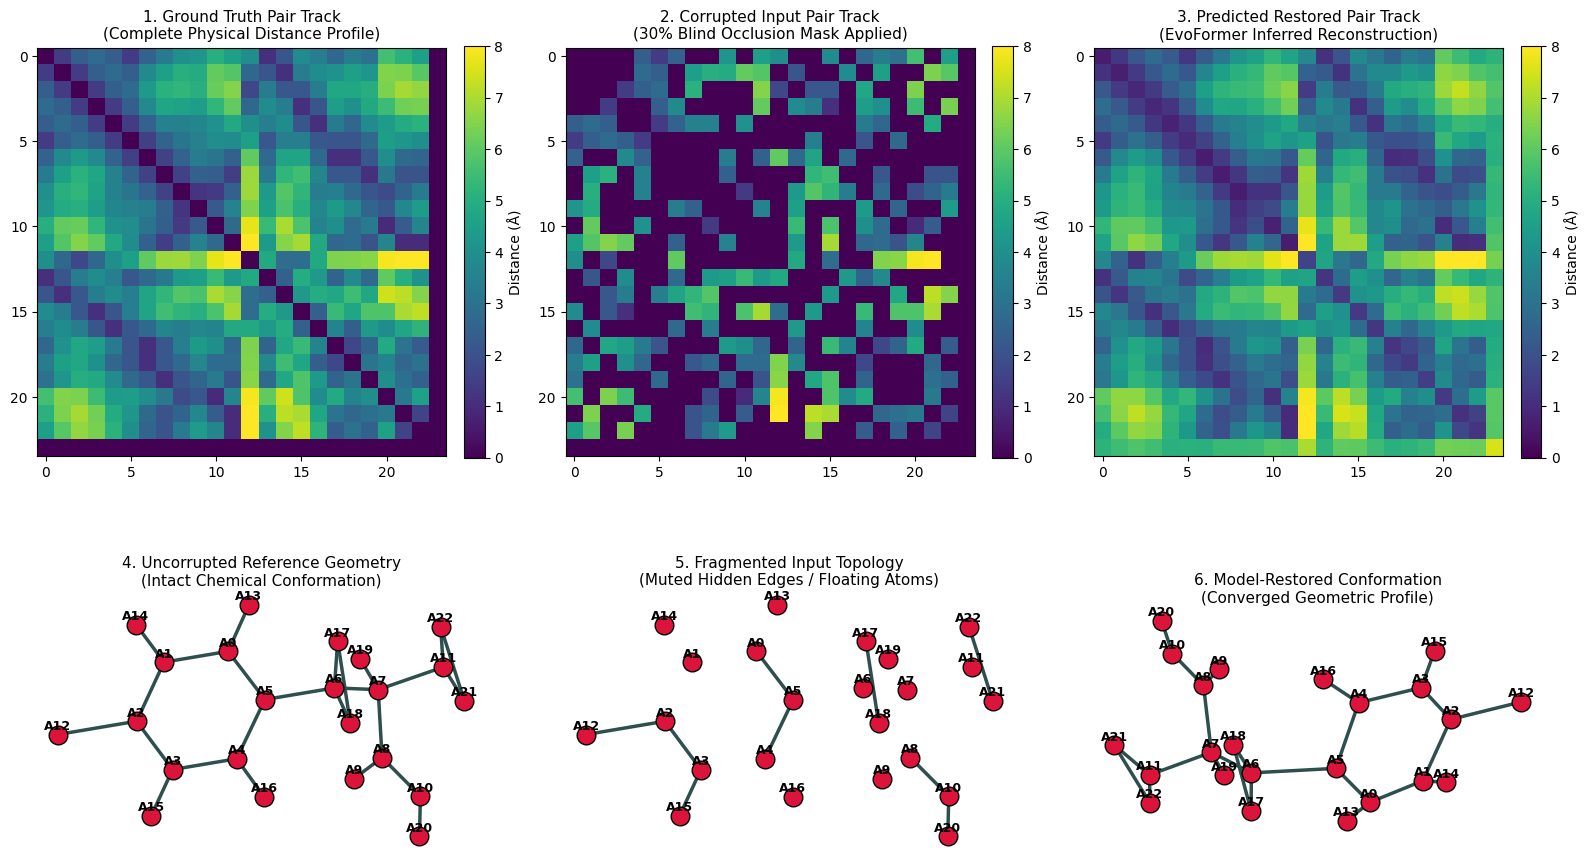

In [ ]:

# 1. Clean Organization: Redirect outputs to the data directory to avoid polluting root
output_dir = './data/evoformer'
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, 'predicted_conformation.png')

model.eval()

# Select a random validation compound from the current evaluation batch
compound_idx = random.randint(0, val_m.size(0) - 1)

with torch.no_grad():
    eval_m = val_m[compound_idx:compound_idx+1]
    eval_z = val_z[compound_idx:compound_idx+1]
    
    # Extract True Physical Ground Truth Matrix
    clean_target_matrix = eval_z[0, :, :, 0].cpu().numpy()
    
    # Create the Corrupted Input Matrix using the spatial mask matrix
    corrupt_eval_z = eval_z.clone()
    np.random.seed(101)
    val_mask = torch.rand(max_atoms, max_atoms, device=device) < 0.30
    val_mask = (val_mask | val_mask.t())
    
    # Apply Mask: Zero out distance channels where mask hits
    corrupt_eval_z[0, :, :, 0] = torch.where(val_mask, torch.zeros_like(corrupt_eval_z[0, :, :, 0]), corrupt_eval_z[0, :, :, 0])
    masked_input_matrix = corrupt_eval_z[0, :, :, 0].cpu().numpy()
    
    # Process through EvoFormer block layers to infer missing geometric positions
    predicted_matrix = model(eval_m, corrupt_eval_z).squeeze(0).cpu().numpy()

# 2. Visualization Layout Setup
fig, ax = plt.subplots(2, 3, figsize=(16, 10))

# --- ROW 1: PAIR TRACK EXTRACTS (DISTANCE HEATMAP MATRICES) ---
im0 = ax[0, 0].imshow(clean_target_matrix, cmap='viridis', vmin=0, vmax=8)
ax[0, 0].set_title("1. Ground Truth Pair Track\n(Complete Physical Distance Profile)", fontsize=11)
fig.colorbar(im0, ax=ax[0, 0], fraction=0.046, pad=0.04).set_label("Distance (Å)")

im1 = ax[0, 1].imshow(masked_input_matrix, cmap='viridis', vmin=0, vmax=8)
ax[0, 1].set_title("2. Corrupted Input Pair Track\n(30% Blind Occlusion Mask Applied)", fontsize=11)
fig.colorbar(im1, ax=ax[0, 1], fraction=0.046, pad=0.04).set_label("Distance (Å)")

im2 = ax[0, 2].imshow(predicted_matrix, cmap='viridis', vmin=0, vmax=8)
ax[0, 2].set_title("3. Predicted Restored Pair Track\n(EvoFormer Inferred Reconstruction)", fontsize=11)
fig.colorbar(im2, ax=ax[0, 2], fraction=0.046, pad=0.04).set_label("Distance (Å)")


# --- ROW 2: STRUCTURAL GRAPH INTERPRETATIONS ---
# Identify valid non-padded atom indices based on non-zero self-distances/atomic entries
valid_atom_mask = (clean_target_matrix.sum(axis=1) > 0)
valid_indices = np.where(valid_atom_mask)[0]

# Generate coordinates using a standard Multidimensional Scaling approach to display the structural maps
def reconstruct_2d_layout(dist_matrix, idxs):
    n = len(idxs)
    if n == 0: return np.zeros((0, 2))
    sub_dist = dist_matrix[np.ix_(idxs, idxs)]
    # Double centering to convert distances into gram dot-product matrix
    H = np.eye(n) - np.ones((n, n)) / n
    B = -0.5 * (H @ (sub_dist ** 2) @ H)
    evals, evecs = np.linalg.eigh(B)
    # Grab top 2 primary coordinate components
    sorted_idx = np.argsort(evals)[::-1]
    coords = evecs[:, sorted_idx[:2]] * np.sqrt(np.maximum(evals[sorted_idx[:2]], 1e-5))
    return coords

orig_coords = reconstruct_2d_layout(clean_target_matrix, valid_indices)
pred_coords = reconstruct_2d_layout(predicted_matrix, valid_indices)

# Define standard physical bond thresholds to draw structural edges (e.g., bonds within 0.5Å to 1.8Å)
def plot_molecular_graph(ax_obj, coords, dist_matrix, idxs, mask_matrix=None, title=""):
    ax_obj.scatter(coords[:, 0], coords[:, 1], c='crimson', s=180, edgecolors='black', zorder=3)
    for i in range(coords.shape[0]):
        ax_obj.text(coords[i, 0], coords[i, 1]+0.1, f"A{idxs[i]}", ha='center', fontsize=9, fontweight='bold')
        
    for i in range(len(idxs)):
        for j in range(i + 1, len(idxs)):
            actual_dist = dist_matrix[idxs[i], idxs[j]]
            if 0.5 <= actual_dist <= 1.8:
                # If checking masked input track, dropped edges will show up as zeroed connections
                if mask_matrix is not None and mask_matrix[idxs[i], idxs[j]] == 0:
                    continue
                ax_obj.plot([coords[i, 0], coords[j, 0]], [coords[i, 1], coords[j, 1]], c='darkslategrey', lw=2.5, zorder=2)
                
    ax_obj.set_title(title, fontsize=11)
    ax_obj.set_aspect('equal')
    ax_obj.axis('off')

# Plot 4: Original reference geometry
plot_molecular_graph(ax[1, 0], orig_coords, clean_target_matrix, valid_indices, title="4. Uncorrupted Reference Geometry\n(Intact Chemical Conformation)")

# Plot 5: Visualizing Hidden Edges / Detached Components
# Passing the masked input array causes hidden connections to be ignored, showing fragmented atoms visually
plot_molecular_graph(ax[1, 1], orig_coords, clean_target_matrix, valid_indices, mask_matrix=masked_input_matrix, 
                     title="5. Fragmented Input Topology\n(Muted Hidden Edges / Floating Atoms)")

# Plot 6: Model Restoration Alignment
plot_molecular_graph(ax[1, 2], pred_coords, predicted_matrix, valid_indices, title="6. Model-Restored Conformation\n(Converged Geometric Profile)")

plt.tight_layout()
plt.savefig(output_path, dpi=120)
plt.show()  # <-- FIX 2: Ensures inline rendering directly within your notebook cell canvas


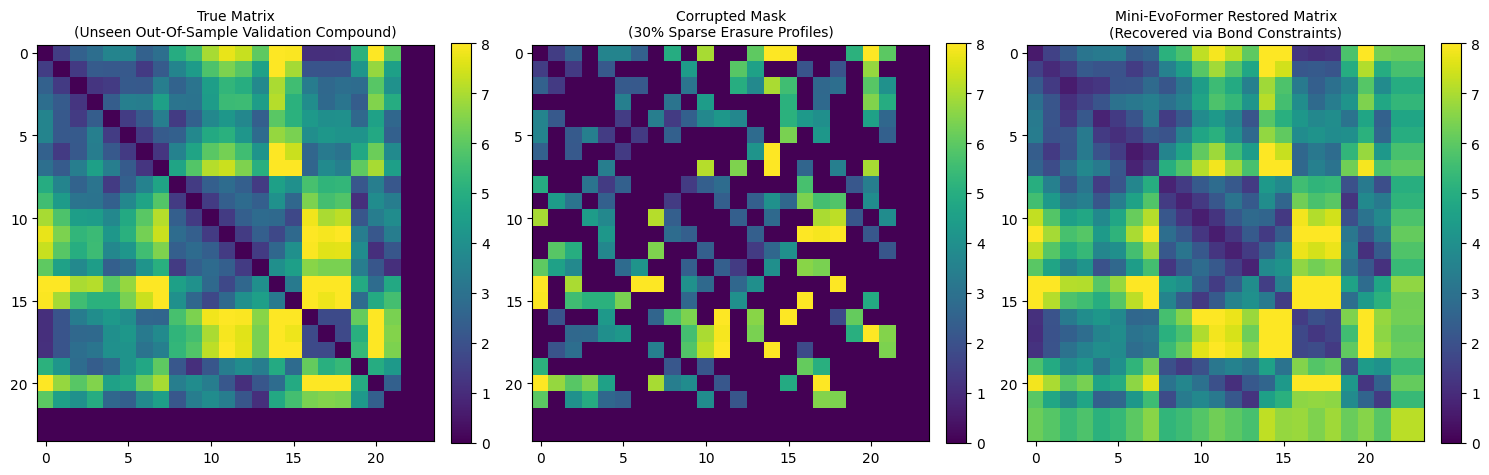

=== Target Molecular Structure Underlying the Experiment ===


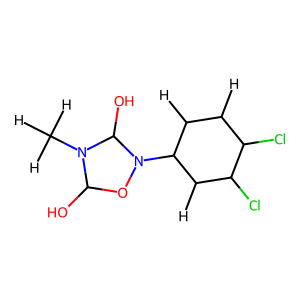

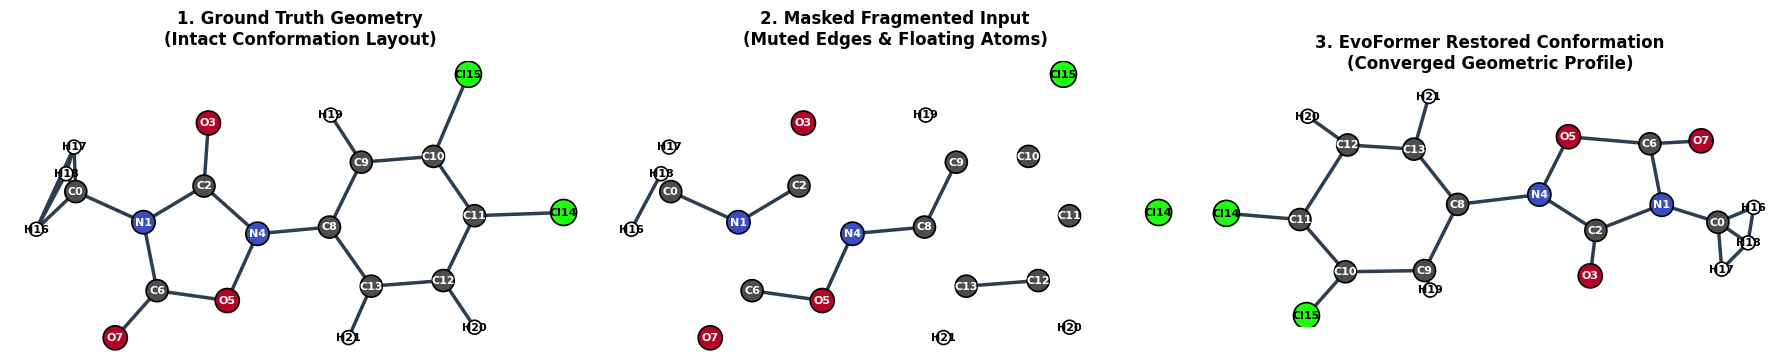

In [20]:
import os
import random
import numpy as np
import torch
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import Draw

# --- 1. Environment & Output Path Setup ---
output_dir = './data/evoformer'
os.makedirs(output_dir, exist_ok=True)
matrix_output_path = os.path.join(output_dir, 'predicted_conformation_matrix.png')
output_path = os.path.join(output_dir, 'predicted_conformation.png')

model.eval()

# --- 2. Data Selection & Extraction ---
compound_idx = random.randint(0, val_m.size(0) - 1)

with torch.no_grad():
    eval_m = val_m[compound_idx:compound_idx+1]
    eval_z = val_z[compound_idx:compound_idx+1]
    
    clean_target_matrix = eval_z[0, :, :, 0].cpu().numpy()
    corrupt_eval_z = eval_z.clone()
    
    # Apply a 30% blind spatial erasure mask
    np.random.seed(101)
    val_mask = torch.rand(max_atoms, max_atoms, device=device) < 0.30
    val_mask = (val_mask | val_mask.t())
    
    corrupt_eval_z[0, :, :, 0] = torch.where(val_mask, torch.zeros_like(corrupt_eval_z[0, :, :, 0]), corrupt_eval_z[0, :, :, 0])
    masked_input_matrix = corrupt_eval_z[0, :, :, 0].cpu().numpy()
    
    # EvoFormer inference recovery pass
    predicted_matrix = model(eval_m, corrupt_eval_z).squeeze(0).cpu().numpy()

# Extract valid atom identities directly from the Node Track
node_atomic_nums = eval_m[0, :, 0].cpu().numpy().astype(int)
valid_atom_mask = (node_atomic_nums > 0)
valid_indices = np.where(valid_atom_mask)[0]
active_atomic_nums = node_atomic_nums[valid_indices]


# --- 3. FIRST step: Render Pairs Matrixes Original/Corrupted/Predicted ---
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
im0 = ax[0].imshow(clean_target_matrix, cmap='viridis', vmin=0, vmax=8)
ax[0].set_title("True Matrix\n(Unseen Out-Of-Sample Validation Compound)", fontsize=10)
fig.colorbar(im0, ax=ax[0], fraction=0.046, pad=0.04)

im1 = ax[1].imshow(masked_input_matrix, cmap='viridis', vmin=0, vmax=8)
ax[1].set_title("Corrupted Mask\n(30% Sparse Erasure Profiles)", fontsize=10)
fig.colorbar(im1, ax=ax[1], fraction=0.046, pad=0.04)

im2 = ax[2].imshow(predicted_matrix, cmap='viridis', vmin=0, vmax=8)
ax[2].set_title("Mini-EvoFormer Restored Matrix\n(Recovered via Bond Constraints)", fontsize=10)
fig.colorbar(im2, ax=ax[2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig(matrix_output_path)
plt.show()
plt.close()

# --- 4. FIRST step: Safely Render the clean canonical 2D RDKit Structure ---
tmp_mol = Chem.RWMol()
atom_idx_map = {}
for i, atomic_num in enumerate(active_atomic_nums):
    a_idx = tmp_mol.AddAtom(Chem.Atom(int(atomic_num)))
    atom_idx_map[i] = a_idx

# Maximum expected common valences to prevent over-bonding during distance sweeps
MAX_VALENCE = {1: 1, 6: 4, 7: 3, 8: 2, 16: 6, 9: 1, 17: 1}

# Map bonds cleanly by sorting pairs by closeness and obeying maximum valences
pairs_by_distance = []
for i in range(len(valid_indices)):
    for j in range(i + 1, len(valid_indices)):
        d = clean_target_matrix[valid_indices[i], valid_indices[j]]
        if 0.5 <= d <= 1.8:
            pairs_by_distance.append((d, i, j))

# Sort to assign closest bonds first (e.g., stable real covalent rings/skeletons)
pairs_by_distance.sort(key=lambda x: x[0])

for d, i, j in pairs_by_distance:
    atom_i = tmp_mol.GetAtomWithIdx(atom_idx_map[i])
    atom_j = tmp_mol.GetAtomWithIdx(atom_idx_map[j])
    
    # Calculate current explicit valence commitments
    val_i = sum([b.GetBondTypeAsDouble() for b in atom_i.GetBonds()])
    val_j = sum([b.GetBondTypeAsDouble() for b in atom_j.GetBonds()])
    
    max_i = MAX_VALENCE.get(atom_i.GetAtomicNum(), 4)
    max_j = MAX_VALENCE.get(atom_j.GetAtomicNum(), 4)
    
    # Only add bond if neither atom breaks their fundamental valence ceiling
    if val_i < max_i and val_j < max_j:
        try:
            tmp_mol.AddBond(atom_idx_map[i], atom_idx_map[j], Chem.BondType.SINGLE)
        except:
            pass

print("=== Target Molecular Structure Underlying the Experiment ===")
# Finalize structure conversion cleanly
final_mol = tmp_mol.GetMol()
Chem.SanitizeMol(final_mol, sanitizeOps=Chem.SanitizeFlags.SANITIZE_ALL ^ Chem.SanitizeFlags.SANITIZE_PROPERTIES)
img = Draw.MolToImage(final_mol, size=(300, 300))
display(img)

# --- 5. Define CPK Element Properties (Colors, Labels, Sizes) ---
CPK_COLORS = {
    1: '#FFFFFF',   # H: White
    6: '#4D4D4D',   # C: Dark Grey
    7: '#3B4CC0',   # N: Blue
    8: '#B40426',   # O: Red
    16: '#E6C100',  # S: Yellow
    9: '#1FFC0E',   # F: Green
    17: '#1FFC0E',  # Cl: Green
}
ELEMENT_LABELS = {1: 'H', 6: 'C', 7: 'N', 8: 'O', 16: 'S', 9: 'F', 17: 'Cl'}
BASE_SIZES = {1: 100, 6: 250, 7: 280, 8: 300, 16: 400, 9: 220, 17: 350}

colors = [CPK_COLORS.get(num, '#9A32CD') for num in active_atomic_nums]
labels = [f"{ELEMENT_LABELS.get(num, 'X')}{valid_indices[i]}" for i, num in enumerate(active_atomic_nums)]
sizes = [BASE_SIZES.get(num, 200) for num in active_atomic_nums]

# --- 6. Geometric Reconstruction & Fragment Wiggling ---
def reconstruct_2d_layout(dist_matrix, idxs):
    n = len(idxs)
    if n == 0: return np.zeros((0, 2))
    sub_dist = dist_matrix[np.ix_(idxs, idxs)]
    H = np.eye(n) - np.ones((n, n)) / n
    B = -0.5 * (H @ (sub_dist ** 2) @ H)
    evals, evecs = np.linalg.eigh(B)
    sorted_idx = np.argsort(evals)[::-1]
    coords = evecs[:, sorted_idx[:2]] * np.sqrt(np.maximum(evals[sorted_idx[:2]], 1e-5))
    return coords

orig_coords = reconstruct_2d_layout(clean_target_matrix, valid_indices)
pred_coords = reconstruct_2d_layout(predicted_matrix, valid_indices)

# Apply Wiggle Perturbation to isolated/fragmented components
corrupted_coords = orig_coords.copy()
for i, idx in enumerate(valid_indices):
    # Determine how many neighbor relationships were preserved for this specific atom
    visible_edges = np.count_nonzero(masked_input_matrix[idx, valid_indices])
    if visible_edges <= 1:  # The atom has lost its structural orientation anchors
        # Displace it randomly to simulate floating away from the core frame
        np.random.seed(42 + idx)
        corrupted_coords[i] += np.random.normal(loc=0.0, scale=1.5, size=(2,))

# --- 7. Custom Graph Plotting Function ---
def plot_molecular_graph(ax_obj, coords, dist_matrix, idxs, mask_matrix=None, title=""):
    # Draw Covalent Bonds
    for i in range(len(idxs)):
        for j in range(i + 1, len(idxs)):
            actual_dist = dist_matrix[idxs[i], idxs[j]]
            if 0.5 <= actual_dist <= 1.8:
                if mask_matrix is not None and mask_matrix[idxs[i], idxs[j]] == 0:
                    continue  # Do not draw masked-out edges
                ax_obj.plot([coords[i, 0], coords[j, 0]], [coords[i, 1], coords[j, 1]], 
                            c='#2C3E50', lw=2.5, zorder=1)
                
    # Draw Atom Nodes using CPK specifications
    scatter = ax_obj.scatter(coords[:, 0], coords[:, 1], c=colors, s=sizes, 
                             edgecolors='black', linewidths=1.2, zorder=2)
    
    # Overlay clear textual element labels
    for i in range(coords.shape[0]):
        text_color = 'white' if active_atomic_nums[i] in [6, 7, 8] else 'black'
        ax_obj.text(coords[i, 0], coords[i, 1], labels[i], ha='center', va='center',
                    fontsize=8, fontweight='bold', color=text_color, zorder=3)
                
    ax_obj.set_title(title, fontsize=12, fontweight='bold', pad=12)
    ax_obj.set_aspect('equal')
    ax_obj.axis('off')

# --- 7. Custom Graph Panel Generation ---
fig, ax = plt.subplots(1, 3, figsize=(18, 6))

# Panel 1: Original Ground Truth Structure
plot_molecular_graph(ax[0], orig_coords, clean_target_matrix, valid_indices, 
                     title="1. Ground Truth Geometry\n(Intact Conformation Layout)")

# Panel 2: Fragmented/Wiggled Input State
plot_molecular_graph(ax[1], corrupted_coords, clean_target_matrix, valid_indices, mask_matrix=masked_input_matrix,
                     title="2. Masked Fragmented Input\n(Muted Edges & Floating Atoms)")

# Panel 3: EvoFormer Restored Alignment
plot_molecular_graph(ax[2], pred_coords, predicted_matrix, valid_indices, 
                     title="3. EvoFormer Restored Conformation\n(Converged Geometric Profile)")

plt.tight_layout()
plt.savefig(output_path, dpi=150)
plt.show()